In [26]:
# ======================
# packages
# ======================

# packages
from pathlib import Path
import ssl
from urllib import request
import ppxf.sps_util as lib
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS

from ppxf.ppxf import robust_sigma

from importlib import resources

from ppxf.ppxf import ppxf
from ppxf.ppxf_util import log_rebin, vac_to_air, air_to_vac
import ppxf.ppxf_util as util

base = Path.cwd()

# speed of light
c = 299792.458 # km/s (everything ppxf outputs is in km/s)

cwd = Path.cwd()
gen_dir = os.path.join(cwd, '..', 'data/')
print(gen_dir)

obj = 'DESJ2112'
filter = 'r'
z_defl = 0.4454
z_src = 2.359

# wavelength range
wavelength_min = 3900
wavelength_max = 5200

# sps used
sps_name = 'emiles'
stellar_libraries = os.path.join(cwd, '..', 'stellar_libraries/')
sps_file = stellar_libraries + f'spectra_{sps_name}_9.0.npz'

/Users/william0billy/Research/DynamicalModeling/codes/../data/


43.634373


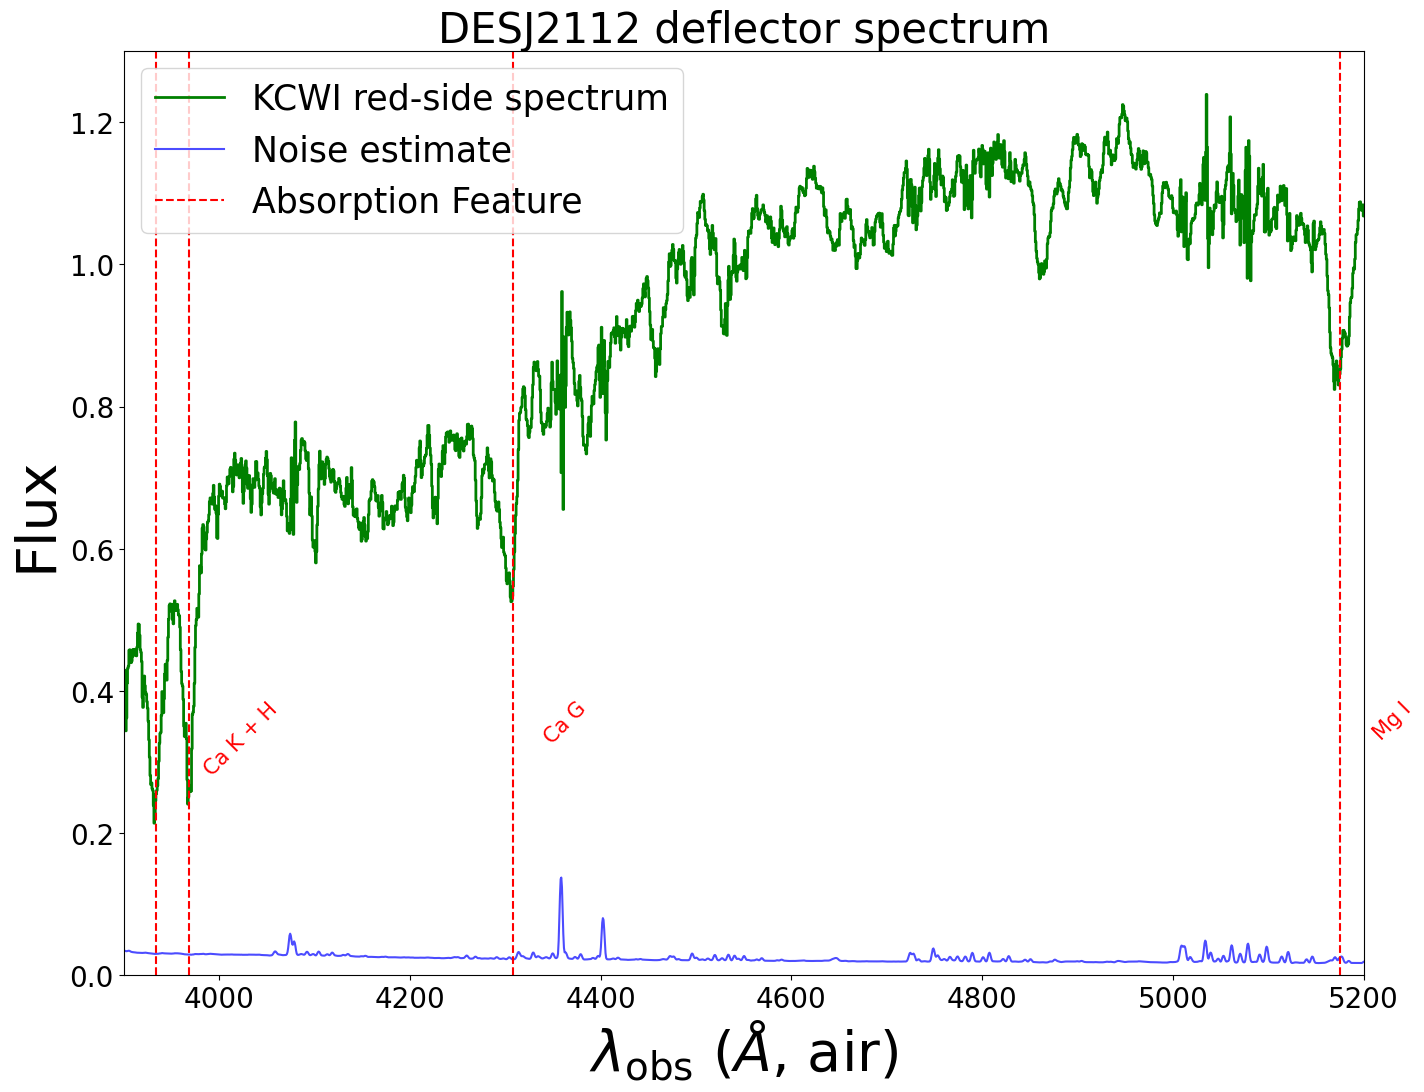

In [27]:
# ===================
# spectrum and noise, we'll define noise for now how Rodrigo defines it, but we will need to update it to be more accurate, plot spectrum and noise
# ===================

spectrum_path = gen_dir + f'{obj}_integrated_defl_{filter}.fits'
cube_path = gen_dir + f'{obj}_{filter}.fits'
noise_path = gen_dir + f'{obj}_integrated_var_{filter}.fits'

with fits.open(cube_path) as hdul:
    cube = hdul[0].data
    hdr = hdul[0].header
    wcs = WCS(hdr)


# ===========
# build wavelength array
# ===========

# extract everything from the cube
ref_lambda = hdr['CRVAL3'] # wavelength zeropoint (beginning wavelength)
if filter == 'r':
    delt = hdr['CD3_3'] # wavelength step size
else:
    delt = hdr['CDELT3'] # wavelength step size (1.0 angstroms per pixel)
npix = hdr['NAXIS3'] # number of wavelength pixels
pix = np.arange(npix) # pixel indices
crpix = hdr.get('CRPIX3', 1.0) # reference pixel (default to 1.0 if not present)
wavelengths = ref_lambda + (pix - crpix) * delt # wavelength array

wavelength_vac = ref_lambda + delt * np.arange(npix) # in angstrom, ref_lambda is start, delt is step size, npix is number of pixels
wavelength_air = vac_to_air(wavelength_vac) # convert to air wavelengths, send to rest frame

# ============
# measure the noise
# ============
deflector_spectrum = fits.open(spectrum_path)[0].data
noise_raw = np.sqrt(fits.open(noise_path)[0].data)

# convert wavelengths to rest frame
wavelength_air = wavelength_air / (1 + z_defl)

# clip spectrum
mask = (wavelength_air > wavelength_min) & (wavelength_air < wavelength_max)
wavelength_air = wavelength_air[mask]
deflector_spectrum = deflector_spectrum[mask]
noise = noise_raw[mask]

# normalize spectrum and noise
deflector_spectrum /= np.median(deflector_spectrum)
noise = noise / np.median(deflector_spectrum)


# absorption lines
rest_absorption_lines_etg = {"": 3933.7, "Ca K + H" : 3968.5, "Ca G" : 
                             4307.74, "Mg I" : 5175.0, "Na": 5895.92}


# plot the spectrum and noise
plt.figure(figsize=(16, 12))
plt.plot(wavelength_air, deflector_spectrum, color='green', lw=2, label='KCWI red-side spectrum', drawstyle='steps-mid')
plt.plot(wavelength_air, noise, color='blue', alpha=0.7, label='Noise estimate')

if filter == 'r':
    plt.xlim(wavelength_min, wavelength_max)
elif filter == 'b':
    plt.xlim(wavelength_min, wavelength_max)

for line_name, line_wavelength in rest_absorption_lines_etg.items():
    if line_wavelength >= plt.xlim()[0] and line_wavelength <= plt.xlim()[1]:
        if line_name == "":
            plt.axvline(x=line_wavelength, color='red', linestyle='--', label = 'Absorption Feature')
        else:
            plt.axvline(x=line_wavelength, color='red', linestyle='--')
        plt.text(line_wavelength + 55, plt.ylim()[1] * 0.3, line_name, rotation=45, verticalalignment='top', horizontalalignment='center', fontsize=15, color = 'red')

plt.ylim(0, 1.3)
plt.xlabel(r'$\lambda_{\rm{obs}}$ ($\AA$, air)', fontsize=40)
plt.ylabel('Flux', fontsize=40)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.title(f'{obj} deflector spectrum', fontsize=30)
plt.legend(fontsize = 25, loc = 'upper left')
print(np.median(deflector_spectrum) / np.median(noise))

In [28]:
# =====================
# basics for velocity dispersion fit
# =====================

# log rebin the spectrum and noise
log_sed, log_wavelength, velscale = log_rebin((wavelength_air[0], wavelength_air[-1]), deflector_spectrum) # rebins the spectrum
log_noise, _, _ = log_rebin((wavelength_air[0], wavelength_air[-1]), np.abs(noise)) # rebins the noise
print(velscale)
# obtain the FWHM of the instrument
dlam_gal = np.gradient(wavelength_air)     # Pixel size in Angstroms
wdisp = delt         # instrumental dispersion in angstroms per pixel
fwhm_gal = 2.355 * wdisp * dlam_gal # instrumental resolution

# create dictionary for FWHM
fwhm_gal = np.median(fwhm_gal) * np.ones_like(wavelength_air)
fwhm_dict = {'lam': wavelength_air, 'fwhm': fwhm_gal}

# lambda range for the stellar template
lam_range = (wavelength_air[0] / 1.1, wavelength_air[-1] * 1.1)

# obtain stellar template library
sps = lib.sps_lib(sps_file, velscale, fwhm_dict, lam_range=lam_range)

# make no estimate right now of goodpixels, will be done later
#goodpixels = 

45.885911515406065


(1880,) (1880,) 45.885911515406065 [0, 300]
Outliers: 4
Outliers: 4
 Best Fit:       Vel     sigma
 comp.  0:       -22       261
chi2/DOF: 0.6735; DOF: 1874; degree = 6; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 23; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/150
260.5269728881124


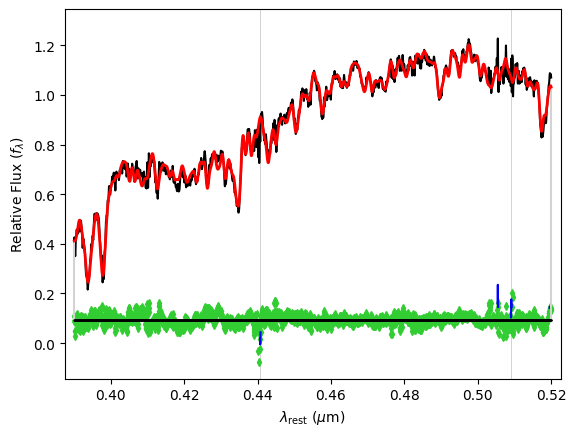

In [29]:
# ======================
# perform the ppxf fit
# ======================

vel_guess = 0 # km/s, initial guess for velocity
sigma_guess = 300 # km/s, initial guess for velocity dispersion

guess = [vel_guess, sigma_guess]
print(log_sed.shape, log_noise.shape, velscale, guess)

pp = ppxf(
    sps.templates, log_sed, log_noise, velscale, guess,
    plot=True, trig=False,clean=True,
    lam=wavelength_air,
    lam_temp=sps.lam_temp, degree=6, mdegree=0)

print(pp.sol[1])


 Best Fit:       Vel     sigma
 comp.  0:       -20       274
chi2/DOF: 0.6958; DOF: 1876; degree = 8; mdegree = 2
method = capfit; Jac calls: 3; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/150
1.0126088662048085
1.0108126884775748
1.0107690757934817
1.0102414766976944
1.0098614589467376
1.0098017578428502
1.0099694681911133
1.0098309775887657
1.0099401567262218


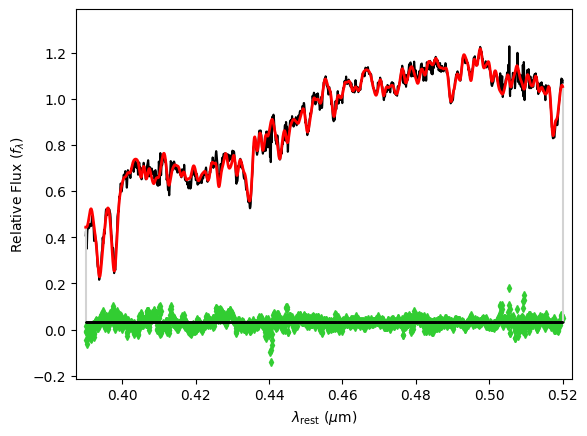

 Best Fit:       Vel     sigma
 comp.  0:       -20       274
chi2/DOF: 0.6848; DOF: 1774; degree = 8; mdegree = 2
method = capfit; Jac calls: 3; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/150
1.0099919248882416
1.0102745441144854


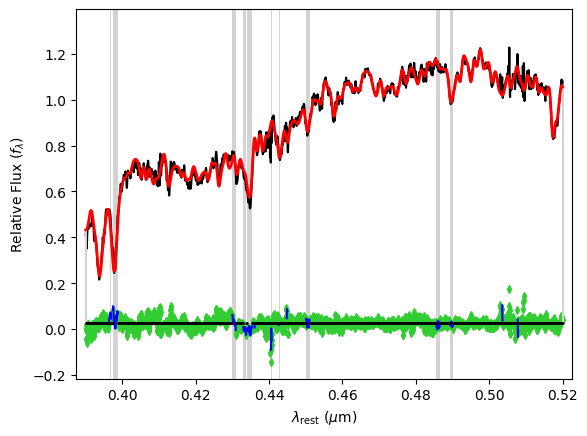

274.48162488044375


In [30]:
# ======================
# perform sigma clipping using the method from Cappellari et al. (2023) eqn 34
# ======================

def clip_outliers(galaxy, bestfit, mask, n_sig=2.5):
    """
    Repeat the fit after clipping bins deviants more than n_sig*sigma in relative
    error until the bad bins don't change any more. This function uses eq.(34)
    of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C


    params
    - galaxy: observed spectrum
    - noise: noise spectrum
    - bestfit: best fit spectrum from ppxf
    - mask: boolean array of good pixels (initially all True)
    - n_sig: number of sigma for clipping (default 3)
    """
    while True: # loops until the mask is unchanged
        scale = galaxy[mask] @ bestfit[mask]/np.sum(bestfit[mask]**2) 
        print(scale) 
        resid = (scale*bestfit[mask] - galaxy[mask])
        err = robust_sigma(resid, zero=3)
        ok_old = mask
        mask = np.abs(scale*bestfit - galaxy) < n_sig*err
        if np.array_equal(mask, ok_old):
            break
    return mask



# apply the sigma clipping to the spectrum

n_iterations = 2

mask_0 = np.ones_like(deflector_spectrum, dtype=bool) # start with all pixels as good
for i in range(n_iterations):
    pp = ppxf(
        sps.templates, log_sed, log_noise, velscale, guess,
        plot=True, trig=True, clean = False,
        lam=wavelength_air,
        lam_temp=sps.lam_temp, degree=8, mdegree = 2, mask=mask_0)
    mask_0 = mask_0 & clip_outliers(deflector_spectrum, pp.bestfit, mask_0)

    plt.show()

print(pp.sol[1])
